In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Feature-based TinyML context pipeline for the SWDP smart glasses.

The model uses only LUMOS/AS7341 spectral data and microphone audio. It does
not use IMU data and it does not feed raw audio directly to the neural network.
"""

from __future__ import annotations

import argparse
import json
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

DRIVE_DATA_DIR = "./data"
DRIVE_DATA_PATH = Path(DRIVE_DATA_DIR)
DRIVE_FEATURES_PATH = DRIVE_DATA_PATH / "output" / "tinyml_features.csv"
DRIVE_MODEL_DIR = DRIVE_DATA_PATH / "output" / "tinyml_context_model"


SUPPORTED_CONTEXT_LABELS = [
    "UNDERGROUND",
    "OUTDOOR",
    "INDOOR_QUIET",
    "INDOOR_NORMAL",
    "COVERED_DARK",
]

LABEL_ALIASES = {
    "UNDERGROUND_TRANSPORT": "UNDERGROUND",
    "TRANSPORT": "UNDERGROUND",
    "SUBWAY": "UNDERGROUND",
    "METRO": "UNDERGROUND",
    "OUT": "OUTDOOR",
    "OUTSIDE": "OUTDOOR",
    "EXTERNAL": "OUTDOOR",
    "LIBRARY": "INDOOR_QUIET",
    "QUIET": "INDOOR_QUIET",
    "STUDY": "INDOOR_QUIET",
    "IN": "INDOOR_NORMAL",
    "INDOOR": "INDOOR_NORMAL",
    "HOME": "INDOOR_NORMAL",
    "OFFICE": "INDOOR_NORMAL",
    "DRAWER": "COVERED_DARK",
    "BAG": "COVERED_DARK",
    "POCKET": "COVERED_DARK",
    "COVERED": "COVERED_DARK",
    "COVERED_DRAWER": "COVERED_DARK",
}

SPECTRO_CHANNELS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "CLEAR", "NIR"]
DEFAULT_AUDIO_SAMPLE_RATE = 16_000.0
DEFAULT_WINDOW_PACKETS = 9
EMBEDDED_FFT_SIZE = 4096
EPS = 1e-8


@dataclass(frozen=True)
class Recording:
    path: Path
    recording_id: str
    label: str
    audio: np.ndarray
    spectro: np.ndarray
    flicker: np.ndarray
    audio_sample_rate: float


LABEL_INDEX_TO_NAME = {
    0: "UNDERGROUND",
    1: "OUTDOOR",
    2: "INDOOR_QUIET",
    3: "INDOOR_NORMAL",
    4: "COVERED_DARK",
}


def canonical_label(raw_label: Any) -> str:
    if isinstance(raw_label, bytes):
        raw_label = raw_label.decode("utf-8")
    if isinstance(raw_label, (int, np.integer)):
        if int(raw_label) not in LABEL_INDEX_TO_NAME:
            raise ValueError(f"Unknown numeric label '{raw_label}'. Expected one of: {LABEL_INDEX_TO_NAME}")
        return LABEL_INDEX_TO_NAME[int(raw_label)]

    label = str(raw_label).strip().upper().replace(" ", "_").replace("-", "_")
    if label.lstrip("+-").isdigit():
        label_index = int(label)
        if label_index not in LABEL_INDEX_TO_NAME:
            raise ValueError(f"Unknown numeric label '{raw_label}'. Expected one of: {LABEL_INDEX_TO_NAME}")
        return LABEL_INDEX_TO_NAME[label_index]

    label = LABEL_ALIASES.get(label, label)
    if label not in SUPPORTED_CONTEXT_LABELS:
        allowed = ", ".join(SUPPORTED_CONTEXT_LABELS)
        raise ValueError(f"Unknown label '{raw_label}'. Expected one of: {allowed}")
    return label


def scalar_from_npz(data: Any, key: str, default: Any = None) -> Any:
    if key not in data.files:
        return default
    value = data[key]
    if np.asarray(value).shape == ():
        return value.item()
    return np.asarray(value).reshape(-1)[0].item()


def read_label(data: Any, path: Path) -> str:
    if "label" in data.files:
        values = np.asarray(data["label"]).reshape(-1)
        unique = sorted({canonical_label(value) for value in values})
        if len(unique) != 1:
            raise ValueError(f"{path.name}: expected one label per recording, found {unique}")
        return unique[0]
    if "labels" in data.files:
        labels = np.asarray(data["labels"]).reshape(-1)
        unique = sorted({canonical_label(value) for value in labels})
        if len(unique) != 1:
            raise ValueError(f"{path.name}: expected one label per recording, found {unique}")
        return unique[0]
    raise ValueError(f"{path.name}: missing 'label' or 'labels' field")


def read_recording(path: Path) -> Recording:
    with np.load(path, allow_pickle=True) as data:
        if "audio" not in data.files:
            raise ValueError(f"{path.name}: missing required 'audio' array")
        if "spectro" not in data.files:
            raise ValueError(f"{path.name}: missing required 'spectro' array")

        audio = np.asarray(data["audio"])
        spectro = np.asarray(data["spectro"], dtype=np.float32)
        flicker = np.asarray(data["flicker"], dtype=np.float32).reshape(-1) if "flicker" in data.files else None
        label = read_label(data, path)

        if audio.ndim != 2:
            raise ValueError(f"{path.name}: 'audio' must have shape (packets, samples)")
        if spectro.ndim != 2 or spectro.shape[1] != len(SPECTRO_CHANNELS):
            raise ValueError(f"{path.name}: 'spectro' must have shape (packets, 10)")
        if spectro.shape[0] != audio.shape[0]:
            raise ValueError(f"{path.name}: audio and spectro packet counts do not match")
        if flicker is None:
            flicker = np.zeros(audio.shape[0], dtype=np.float32)
        if flicker.shape[0] != audio.shape[0]:
            raise ValueError(f"{path.name}: flicker and audio packet counts do not match")

        audio_sample_rate = float(scalar_from_npz(data, "audio_sample_rate", DEFAULT_AUDIO_SAMPLE_RATE))

    return Recording(
        path=path,
        recording_id=path.stem,
        label=label,
        audio=audio.astype(np.float32),
        spectro=spectro,
        flicker=flicker.astype(np.float32),
        audio_sample_rate=audio_sample_rate,
    )


def safe_ratio(num: np.ndarray | float, den: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(num) / (np.asarray(den) + EPS)


def embedded_audio_spectrum_features(signal: np.ndarray, sample_rate: float) -> tuple[dict[str, float], float]:
    """Match the firmware FFT feature extraction.

    The C implementation uses 8192-point Hann-windowed FFT blocks over the
    complete 9-packet audio window, then accumulates power bands and centroid
    terms. This replaces the previous full-window np.fft.rfft() so the model is
    trained on features that match the embedded firmware.
    """
    if signal.size == 0:
        signal = np.zeros(1, dtype=np.float32)

    fft_size = EMBEDDED_FFT_SIZE
    hann = np.hanning(fft_size).astype(np.float32)
    freqs = np.fft.rfftfreq(fft_size, d=1.0 / sample_rate)

    bands = {
        "low": 0.0,
        "mid": 0.0,
        "high": 0.0,
        "very_high": 0.0,
    }
    centroid_num = 0.0
    centroid_den = 0.0

    for start in range(0, signal.size, fft_size):
        block = signal[start : start + fft_size]
        if block.size < fft_size:
            padded = np.zeros(fft_size, dtype=np.float32)
            padded[: block.size] = block
            block = padded

        spectrum = np.fft.rfft(block * hann)
        power = (spectrum.real * spectrum.real) + (spectrum.imag * spectrum.imag)
        magnitude = np.sqrt(power) + EPS

        bands["low"] += float(power[(freqs >= 20.0) & (freqs < 250.0)].sum())
        bands["mid"] += float(power[(freqs >= 250.0) & (freqs < 1000.0)].sum())
        bands["high"] += float(power[(freqs >= 1000.0) & (freqs < 4000.0)].sum())
        bands["very_high"] += float(power[(freqs >= 4000.0) & (freqs < 7900.0)].sum())

        centroid_num += float((freqs * magnitude).sum())
        centroid_den += float(magnitude.sum())

    centroid = centroid_num / (centroid_den + EPS)
    return bands, float(centroid)


def extract_spectro_features(spectro_window: np.ndarray) -> dict[str, float]:
    visible = spectro_window[:, :8]
    clear = spectro_window[:, 8]
    nir = spectro_window[:, 9]
    channel_means = spectro_window.mean(axis=0)
    clear_mean = float(clear.mean())
    visible_sum = visible.sum(axis=1)
    visible_mean = float(visible_sum.mean())

    features: dict[str, float] = {
        "lumos_total_log": float(np.log1p(spectro_window.sum(axis=1).mean())),
        "lumos_clear_log": float(np.log1p(clear_mean)),
        "lumos_nir_clear_ratio": float(safe_ratio(nir.mean(), clear_mean)),
        "lumos_clear_std_ratio": float(safe_ratio(clear.std(), clear_mean)),
        "lumos_visible_std_ratio": float(safe_ratio(visible_sum.std(), visible_mean)),
        "lumos_blue_red_ratio": float(safe_ratio(channel_means[0] + channel_means[1], channel_means[6] + channel_means[7])),
        "lumos_green_red_ratio": float(safe_ratio(channel_means[3] + channel_means[4], channel_means[6] + channel_means[7])),
        "lumos_dark_fraction": float(np.mean((clear < 10.0) & (visible_sum < 80.0))),
        "lumos_saturation_fraction": float(np.mean(spectro_window >= 65000.0)),
    }

    for idx, name in enumerate(SPECTRO_CHANNELS[:8]):
        features[f"lumos_{name.lower()}_clear_ratio"] = float(safe_ratio(channel_means[idx], clear_mean))

    return features


def extract_audio_features(audio_window: np.ndarray, sample_rate: float) -> dict[str, float]:
    x = audio_window.astype(np.float32).reshape(-1) / 32768.0
    if x.size == 0:
        x = np.zeros(1, dtype=np.float32)
    abs_x = np.abs(x)
    rms = float(np.sqrt(np.mean(x * x)))
    peak = float(abs_x.max())
    zc = float(np.mean(np.diff(np.signbit(x)) != 0)) if x.size > 1 else 0.0

    bands, centroid = embedded_audio_spectrum_features(x, sample_rate)
    total_band_energy = sum(bands.values()) + EPS

    features = {
        "audio_rms": rms,
        "audio_log_energy": float(np.log1p(np.mean(x * x))),
        "audio_abs_mean": float(abs_x.mean()),
        "audio_std": float(x.std()),
        "audio_peak": peak,
        "audio_crest_factor": float(peak / (rms + EPS)),
        "audio_silence_fraction": float(np.mean(abs_x < 0.005)),
        "audio_zero_crossing_rate": zc,
        "audio_low_high_ratio": float((bands["low"] + EPS) / (bands["high"] + bands["very_high"] + EPS)),
        "audio_spectral_centroid_hz": centroid,
    }

    for name, value in bands.items():
        features[f"audio_{name}_band_log"] = float(np.log1p(value))
        features[f"audio_{name}_band_ratio"] = float(value / total_band_energy)

    return features


def extract_flicker_features(flicker_window: np.ndarray) -> dict[str, float]:
    values = flicker_window.astype(np.float32).reshape(-1)
    if values.size == 0:
        values = np.zeros(1, dtype=np.float32)
    known = np.isin(values, [0.0, 1.0, 2.0, 3.0])
    return {
        "flicker_sensor_off_fraction": float(np.mean(values == 0.0)),
        "flicker_none_fraction": float(np.mean(values == 1.0)),
        "flicker_100hz_fraction": float(np.mean(values == 2.0)),
        "flicker_120hz_fraction": float(np.mean(values == 3.0)),
        "flicker_detected_fraction": float(np.mean((values == 2.0) | (values == 3.0))),
        "flicker_unknown_fraction": float(np.mean(~known)),
    }


def extract_recording_features(recording: Recording, window_packets: int) -> list[dict[str, Any]]:
    packet_duration = recording.audio.shape[1] / recording.audio_sample_rate
    window_packets = max(1, int(window_packets))
    rows: list[dict[str, Any]] = []

    for start in range(0, recording.audio.shape[0] - window_packets + 1, window_packets):
        end = start + window_packets
        row: dict[str, Any] = {
            "recording_id": recording.recording_id,
            "source_file": recording.path.name,
            "label": recording.label,
            "window_start_packet": start,
            "window_end_packet": end,
            "window_start_s": round(start * packet_duration, 3),
            "window_end_s": round(end * packet_duration, 3),
        }
        row.update(extract_spectro_features(recording.spectro[start:end]))
        row.update(extract_flicker_features(recording.flicker[start:end]))
        row.update(extract_audio_features(recording.audio[start:end], recording.audio_sample_rate))
        rows.append(row)

    return rows


def npz_files(data_dir: Path) -> list[Path]:
    return sorted(path for path in data_dir.glob("*.npz") if path.is_file())


def feature_columns(df: pd.DataFrame) -> list[str]:
    excluded = {"recording_id", "source_file", "label", "window_start_packet", "window_end_packet", "window_start_s", "window_end_s"}
    return [col for col in df.columns if col not in excluded]


def observed_labels_in_order(labels: Iterable[str]) -> list[str]:
    present = set(labels)
    ordered = [label for label in SUPPORTED_CONTEXT_LABELS if label in present]
    extras = sorted(present.difference(SUPPORTED_CONTEXT_LABELS))
    return ordered + extras


def save_json(path: Path, payload: dict[str, Any]) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def build_features(args: argparse.Namespace) -> None:
    files = npz_files(args.data_dir)
    if not files:
        raise FileNotFoundError(f"No .npz files found in {args.data_dir}")

    rows: list[dict[str, Any]] = []
    errors: list[str] = []
    for path in files:
        try:
            rows.extend(extract_recording_features(read_recording(path), args.window_packets))
        except Exception as exc:
            errors.append(f"{path.name}: {exc}")

    if errors and not args.skip_bad_files:
        raise RuntimeError("Feature extraction failed:\n" + "\n".join(errors))
    if not rows:
        raise RuntimeError("No feature rows were generated")

    out = args.out
    out.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(rows)
    df.to_csv(out, index=False)

    metadata = {
        "supported_labels": SUPPORTED_CONTEXT_LABELS,
        "label_index_to_name": LABEL_INDEX_TO_NAME,
        "observed_labels": observed_labels_in_order(df["label"].unique()),
        "window_packets": args.window_packets,
        "feature_columns": feature_columns(df),
        "rows": int(len(df)),
        "recordings": int(df["recording_id"].nunique()),
        "class_counts": df["label"].value_counts().to_dict(),
        "sensors": ["spectro", "flicker", "audio"],
        "errors_skipped": errors,
    }
    out.with_suffix(".metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print(f"Wrote {len(df)} feature windows to {out}")
    print(f"Class counts: {metadata['class_counts']}")
    if errors:
        print(f"Skipped {len(errors)} file(s); see {out.with_suffix('.metadata.json')}")


def class_weight_dict(y_indices: np.ndarray) -> dict[int, float]:
    from sklearn.utils.class_weight import compute_class_weight

    present = np.unique(y_indices)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_indices)
    return {int(cls): float(weight) for cls, weight in zip(present, weights)}


def split_dataset(
    df: pd.DataFrame,
    y: np.ndarray,
    test_size: float,
    random_state: int,
) -> tuple[np.ndarray, np.ndarray, str, str | None]:
    from sklearn.model_selection import GroupShuffleSplit, train_test_split

    labels = set(df["label"])
    recordings_per_label = df.groupby("label")["recording_id"].nunique()

    if len(df["recording_id"].unique()) >= 2 and recordings_per_label.min() >= 2:
        groups = df["recording_id"].to_numpy()
        splitter = GroupShuffleSplit(n_splits=100, test_size=test_size, random_state=random_state)
        for train_idx, test_idx in splitter.split(df, y, groups):
            if set(df.iloc[train_idx]["label"]) == labels and set(df.iloc[test_idx]["label"]) == labels:
                return train_idx, test_idx, "GroupShuffleSplit by recording_id", None

    warning = (
        "Only one recording is available for at least one class, so the split falls back to "
        "stratified windows. This verifies the pipeline, but it is not a robust scientific "
        "generalization test."
    )
    indices = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return train_idx, test_idx, "Stratified train_test_split by window", warning


def build_model(input_dim: int, num_classes: int):
    import keras

    model = keras.Sequential(
        [
            keras.Input(shape=(input_dim,), name="context_features"),
            keras.layers.Dense(32, activation="relu", name="dense_32"),
            keras.layers.Dense(16, activation="relu", name="dense_16"),
            keras.layers.Dense(num_classes, activation="softmax", name="context_probs"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def export_int8_tflite(model: Any, representative_x: np.ndarray, out_path: Path) -> dict[str, Any]:
    import tensorflow as tf

    def representative_dataset() -> Iterable[list[np.ndarray]]:
        count = min(100, representative_x.shape[0])
        for idx in range(count):
            yield [representative_x[idx : idx + 1].astype(np.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    out_path.write_bytes(tflite_model)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    return {
        "path": str(out_path),
        "size_bytes": len(tflite_model),
        "input_shape": [int(x) for x in input_details["shape"]],
        "output_shape": [int(x) for x in output_details["shape"]],
        "input_quantization": {
            "scale": float(input_details["quantization"][0]),
            "zero_point": int(input_details["quantization"][1]),
            "dtype": str(input_details["dtype"]),
        },
        "output_quantization": {
            "scale": float(output_details["quantization"][0]),
            "zero_point": int(output_details["quantization"][1]),
            "dtype": str(output_details["dtype"]),
        },
    }


def verify_tflite(tflite_path: Path, sample_x: np.ndarray, expected_input_dim: int, expected_output_dim: int) -> dict[str, Any]:
    import tensorflow as tf

    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_shape = input_details["shape"].tolist()
    output_shape = output_details["shape"].tolist()
    if input_shape != [1, expected_input_dim]:
        raise RuntimeError(f"TFLite input shape {input_shape} does not match [1, {expected_input_dim}]")
    if output_shape != [1, expected_output_dim]:
        raise RuntimeError(f"TFLite output shape {output_shape} does not match [1, {expected_output_dim}]")

    in_scale, in_zero = input_details["quantization"]
    if input_details["dtype"] == np.int8:
        model_input = np.clip(np.round(sample_x / in_scale + in_zero), -128, 127).astype(np.int8)
    else:
        model_input = sample_x.astype(input_details["dtype"])

    interpreter.set_tensor(input_details["index"], model_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details["index"])

    return {
        "input_shape": input_shape,
        "output_shape": output_shape,
        "sample_output": output.reshape(-1).astype(float).tolist(),
    }


def train_model(args: argparse.Namespace) -> None:
    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
        import keras
    except ModuleNotFoundError as exc:
        raise RuntimeError(
            "Training requires scikit-learn, TensorFlow, and Keras. Install the project requirements with "
            "'python -m pip install -r requirements.txt'."
        ) from exc

    df = pd.read_csv(args.features)
    columns = feature_columns(df)
    if not columns:
        raise ValueError("No feature columns found")
    imu_columns = [col for col in columns if col.startswith("imu_")]
    if imu_columns:
        raise ValueError(f"Unexpected IMU feature columns found: {imu_columns}")

    labels = observed_labels_in_order(df["label"].unique())
    if len(labels) < 2:
        raise ValueError("Need at least two observed labels to train a classifier")

    label_to_index = {label: idx for idx, label in enumerate(labels)}
    y = df["label"].map(label_to_index).to_numpy(dtype=np.int64)
    x = df[columns].to_numpy(dtype=np.float32)

    train_idx, test_idx, split_strategy, split_warning = split_dataset(df, y, args.test_size, args.random_state)
    x_train_raw, x_test_raw = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    mean = x_train_raw.mean(axis=0)
    std = x_train_raw.std(axis=0)
    std[std < 1e-6] = 1.0
    x_train = (x_train_raw - mean) / std
    x_test = (x_test_raw - mean) / std

    out_dir = args.out_dir
    out_dir.mkdir(parents=True, exist_ok=True)

    baseline = LogisticRegression(max_iter=1000, class_weight="balanced")
    baseline.fit(x_train, y_train)
    baseline_pred = baseline.predict(x_test)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=args.patience,
            restore_best_weights=True,
        )
    ]

    model = build_model(input_dim=x_train.shape[1], num_classes=len(labels))
    history = model.fit(
        x_train,
        y_train,
        validation_split=args.validation_split,
        epochs=args.epochs,
        batch_size=args.batch_size,
        callbacks=callbacks,
        class_weight=class_weight_dict(y_train),
        verbose=2,
    )

    pred_prob = model.predict(x_test, verbose=0)
    pred = np.argmax(pred_prob, axis=1)

    report = classification_report(
        y_test,
        pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_test, pred, labels=list(range(len(labels))))

    np.savetxt(out_dir / "confusion_matrix.csv", cm, delimiter=",", fmt="%d")
    model.save(out_dir / "keras_model.keras")

    tflite_path = out_dir / "tinyml_context_model_int8.tflite"
    tflite_info = export_int8_tflite(model, x_train, tflite_path)
    tflite_verification = verify_tflite(tflite_path, x_test[0:1], x_train.shape[1], len(labels))

    metadata = {
        "supported_labels": SUPPORTED_CONTEXT_LABELS,
        "labels": labels,
        "feature_columns": columns,
        "normalization": {
            "mean": {col: float(value) for col, value in zip(columns, mean)},
            "std": {col: float(value) for col, value in zip(columns, std)},
        },
        "windowing": {
            "window_packets": scalar_from_features_metadata(args.features, "window_packets", DEFAULT_WINDOW_PACKETS),
            "split": split_strategy,
            "split_warning": split_warning,
        },
        "model": {
            "architecture": ["Dense(32, relu)", "Dense(16, relu)", f"Dense({len(labels)}, softmax)"],
            "input_dim": int(x_train.shape[1]),
            "output_dim": len(labels),
            "epochs_trained": len(history.history.get("loss", [])),
            "sensors": ["spectro", "flicker", "audio"],
        },
        "metrics": {
            "accuracy": float(accuracy_score(y_test, pred)),
            "macro_f1": float(f1_score(y_test, pred, average="macro", zero_division=0)),
            "baseline_logistic_accuracy": float(accuracy_score(y_test, baseline_pred)),
            "baseline_logistic_macro_f1": float(f1_score(y_test, baseline_pred, average="macro", zero_division=0)),
            "classification_report": report,
        },
        "tflite": tflite_info,
        "tflite_verification": tflite_verification,
        "class_counts": df["label"].value_counts().to_dict(),
        "train_recordings": sorted(df.iloc[train_idx]["recording_id"].unique().tolist()),
        "test_recordings": sorted(df.iloc[test_idx]["recording_id"].unique().tolist()),
    }

    save_json(out_dir / "model_metadata.json", metadata)
    save_json(out_dir / "labels.json", {"labels": labels, "label_to_index": label_to_index})
    save_json(out_dir / "feature_normalization.json", metadata["normalization"])
    save_json(out_dir / "feature_columns.json", {"feature_columns": columns})

    print(f"Wrote model artifacts to {out_dir}")
    print(f"Labels: {labels}")
    print(f"Accuracy: {metadata['metrics']['accuracy']:.3f}")
    print(f"Macro F1: {metadata['metrics']['macro_f1']:.3f}")
    print(f"TFLite int8 size: {tflite_info['size_bytes']} bytes")
    if split_warning:
        print(f"WARNING: {split_warning}")


def scalar_from_features_metadata(features_csv: Path, key: str, default: Any) -> Any:
    metadata_path = features_csv.with_suffix(".metadata.json")
    if not metadata_path.exists():
        return default
    try:
        return json.loads(metadata_path.read_text(encoding="utf-8")).get(key, default)
    except json.JSONDecodeError:
        return default


def inspect_npz(args: argparse.Namespace) -> None:
    files = npz_files(args.data_dir)
    if not files:
        raise FileNotFoundError(f"No .npz files found in {args.data_dir}")
    for path in files:
        with np.load(path, allow_pickle=True) as data:
            print(path.name)
            for key in data.files:
                arr = np.asarray(data[key])
                print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")


def parse_args(input_args: list[str] | None = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="TinyML context model pipeline for SWDP smart glasses")
    sub = parser.add_subparsers(dest="command", required=True)

    inspect = sub.add_parser("inspect-npz", help="Print the schema of NPZ recordings")
    inspect.add_argument("--data-dir", type=Path, default=DRIVE_DATA_PATH)
    inspect.set_defaults(func=inspect_npz)

    features = sub.add_parser("build-features", help="Build window-level feature CSV from recording NPZ files")
    features.add_argument("--data-dir", type=Path, default=DRIVE_DATA_PATH)
    features.add_argument("--out", type=Path, default=DRIVE_FEATURES_PATH)
    features.add_argument("--window-packets", type=int, default=DEFAULT_WINDOW_PACKETS)
    features.add_argument("--skip-bad-files", action="store_true", help="Skip invalid recordings instead of failing")
    features.set_defaults(func=build_features)

    train = sub.add_parser("train", help="Train and export the compact int8 MLP")
    train.add_argument("--features", type=Path, default=DRIVE_FEATURES_PATH)
    train.add_argument("--out-dir", type=Path, default=DRIVE_MODEL_DIR)
    train.add_argument("--test-size", type=float, default=0.2)
    train.add_argument("--validation-split", type=float, default=0.2)
    train.add_argument("--epochs", type=int, default=120)
    train.add_argument("--batch-size", type=int, default=16)
    train.add_argument("--patience", type=int, default=15)
    train.add_argument("--random-state", type=int, default=42)
    train.set_defaults(func=train_model)

    return parser.parse_args(input_args)


def main(input_args: list[str] | None = None) -> None:
    args = parse_args(input_args)
    try:
        args.func(args)
    except Exception as exc:
        raise SystemExit(f"ERROR: {exc}") from exc


def colab_inspect_npz(data_dir: str | Path = DRIVE_DATA_PATH) -> None:
    main(["inspect-npz", "--data-dir", str(data_dir)])


def colab_build_features(
    data_dir: str | Path = DRIVE_DATA_PATH,
    out: str | Path = DRIVE_FEATURES_PATH,
    window_packets: int = DEFAULT_WINDOW_PACKETS,
    skip_bad_files: bool = False,
) -> None:
    args = [
        "build-features",
        "--data-dir",
        str(data_dir),
        "--out",
        str(out),
        "--window-packets",
        str(window_packets),
    ]
    if skip_bad_files:
        args.append("--skip-bad-files")
    main(args)


def colab_train(
    features: str | Path = DRIVE_FEATURES_PATH,
    out_dir: str | Path = DRIVE_MODEL_DIR,
    test_size: float = 0.2,
    validation_split: float = 0.2,
    epochs: int = 120,
    batch_size: int = 16,
    patience: int = 15,
    random_state: int = 42,
) -> None:
    main(
        [
            "train",
            "--features",
            str(features),
            "--out-dir",
            str(out_dir),
            "--test-size",
            str(test_size),
            "--validation-split",
            str(validation_split),
            "--epochs",
            str(epochs),
            "--batch-size",
            str(batch_size),
            "--patience",
            str(patience),
            "--random-state",
            str(random_state),
        ]
    )


def colab_run_all(data_dir: str | Path = DRIVE_DATA_PATH) -> None:
    data_dir = Path(data_dir)
    features_path = data_dir / "output" / "tinyml_features.csv"
    model_dir = data_dir / "output" / "tinyml_context_model"
    colab_inspect_npz(data_dir)
    colab_build_features(data_dir=data_dir, out=features_path)
    colab_train(features=features_path, out_dir=model_dir)


if __name__ == "__main__":
    try:
        get_ipython  # type: ignore[name-defined]
        colab_run_all()
    except NameError:
        main()


InsideBag_dataset.npz
  spectro: shape=(1011, 10), dtype=uint16
  audio: shape=(1011, 6102), dtype=int16
  flicker: shape=(1011,), dtype=uint32
  label: shape=(1011,), dtype=int8
OutsideSunShade_dataset.npz
  spectro: shape=(986, 10), dtype=uint16
  flicker: shape=(986,), dtype=uint32
  audio: shape=(986, 6102), dtype=int16
  label: shape=(986,), dtype=int8
OutsideSunWalking_dataset.npz
  spectro: shape=(228, 10), dtype=uint16
  audio: shape=(228, 6102), dtype=int16
  flicker: shape=(228,), dtype=uint32
  label: shape=(228,), dtype=int8
RoomTalking_dataset.npz
  spectro: shape=(1589, 10), dtype=uint16
  audio: shape=(1589, 6102), dtype=int16
  flicker: shape=(1589,), dtype=uint32
  label: shape=(1589,), dtype=int8
StudyRoom_dataset.npz
  spectro: shape=(1026, 10), dtype=uint16
  flicker: shape=(1026,), dtype=uint32
  audio: shape=(1026, 6102), dtype=int16
  label: shape=(1026,), dtype=int8
Underground_dataset.npz
  spectro: shape=(767, 10), dtype=uint16
  flicker: shape=(767,), dtype=u

INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpwuj42946/assets


Saved artifact at '/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpwuj42946'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 41), dtype=tf.float32, name='context_features')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  4888644880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4888645648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4888645264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4888644688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4888646032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4888643920: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/mirko/Developer/SWDPProject/pipeline/venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781800789.644351 1099192 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781800789.644545 1099192 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781800789.645198 1099192 reader.cc:83] Reading SavedModel from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpwuj42946
I0000 00:00:1781800789.645466 1099192 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781800789.645470 1099192 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpwuj42946
I0000 00:00:1781800789.648548 1099192 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781800789.659627 1099192 loader.cc:220] Running initialization op on SavedModel b

Wrote model artifacts to data/output/tinyml_context_model
Labels: ['UNDERGROUND', 'OUTDOOR', 'INDOOR_QUIET', 'INDOOR_NORMAL', 'COVERED_DARK']
Accuracy: 1.000
Macro F1: 1.000
TFLite int8 size: 6000 bytes


.716391 1099192 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
/Users/mirko/Developer/SWDPProject/pipeline/venv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


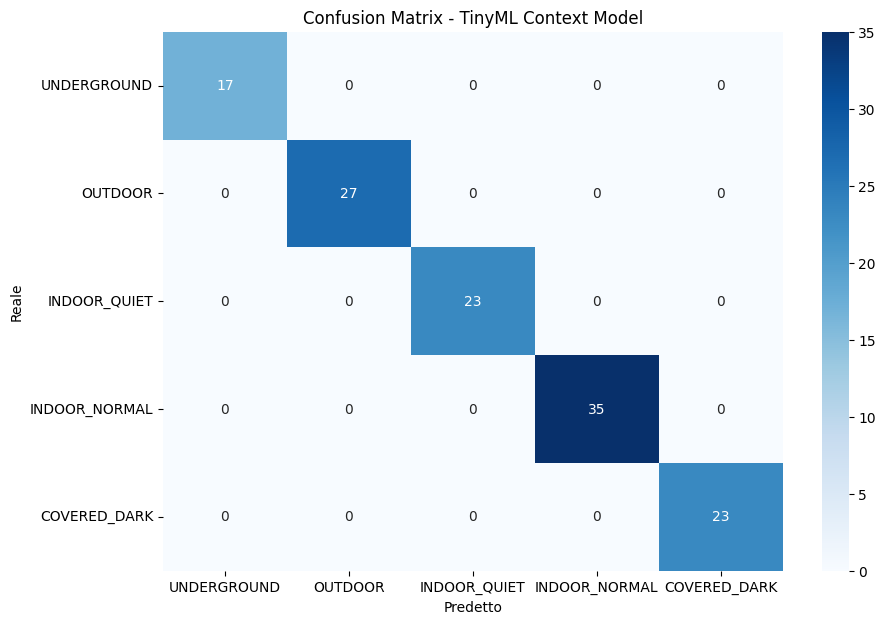

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Percorsi dei file
cm_path = Path(DRIVE_MODEL_DIR) / "confusion_matrix.csv"
labels_path = Path(DRIVE_MODEL_DIR) / "labels.json"

if cm_path.exists() and labels_path.exists():
    # Carica le etichette utilizzate durante il training
    with open(labels_path, 'r') as f:
        labels_data = json.load(f)
        classes = labels_data['labels']

    # Carica la matrice di confusione
    cm = pd.read_csv(cm_path, header=None).values

    # Visualizzazione
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.title('Confusion Matrix - TinyML Context Model')
    plt.show()
else:
    print(f"Errore: File non trovati in {DRIVE_MODEL_DIR}. Assicurati di aver eseguito il training.")